In [ ]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / ".git").exists():
            return p
    raise RuntimeError("Could not locate project root (no .git found above cwd)")

PROJECT_ROOT = _find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments" / "concept_drift"


# Concept Drift Detection on Synthetic Artifacts (MLP)

This notebook runs adjacent-year discrimination on synthetic artifacts generated in
`data drift testing on syntetic data.ipynb`, using an MLP (multi-layer perceptron) classifier
instead of the linear SGD discriminator used in `concept_drift_detection_with_syntetic_data-disc.ipynb`.
The rest of the pipeline (manifest, splits, checkpointing) is identical, so results are directly
comparable between the two notebooks.

Workflow summary:
- Load synthetic artifact manifest from `synthetic_drift_data/`
- Reuse train/val/test pixel splits from `data_split.npz`
- Run the same MLP discriminator pipeline for each artifact
- Organize execution by synthetic method type:
  - Mean/variance shift
  - Covariance shift
  - Noise injection

Each method section runs every `(mode, severity)` artifact available for that method — the
generator now sweeps a list of severity levels per method, so there are typically several
artifacts per mode, not one. Each is uniquely identified by `artifact_label` (method | mode |
severity) and results are grouped/plotted by severity to show a detection-power-vs-magnitude
curve rather than being averaged away.

A high ROC-AUC indicates stronger separability between adjacent years (drift signal).

If an artifact's metadata has `class_filter` set (concept-drift artifacts, where the
perturbation only touched pixels of one disturbance class), this notebook also reports AUC
restricted to that class's pixels (`*_auc_class_filtered`) alongside the whole-population AUC
— the whole-population number can understate a concept-drift signal that only affects a small
subset of pixels.

**Resumability:** every `(artifact, year-pair)` result is checkpointed to
`mlp_checkpoints_synthetic_drift/mlp_discriminator_results.pkl` as soon as it's computed.
If the kernel is interrupted or restarted, re-running the notebook picks up where it left off —
already-computed pairs print `CACHED: ...` and are not refit. Call `clear_results_checkpoint()`
if you change the modeling pipeline and want to force a full recompute.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Paths
split_path = str(PROJECT_ROOT / "data_split.npz")
manifest_json_path = PROJECT_ROOT / "synthetic_drift_data" / "synthetic_generation_manifest.json"
manifest_csv_path = PROJECT_ROOT / "synthetic_drift_data" / "synthetic_generation_manifest.csv"
original_data_path = str(PROJECT_ROOT / "training_data_with_features.zarr")  # unmodified source, used as a reference baseline

# Checkpointing (resumability): every (artifact, year-pair) result is persisted here as soon
# as it's computed, so an interrupted/restarted run can skip already-completed pairs.
CHECKPOINT_DIR = EXPERIMENTS_DIR / "mlp_checkpoints_synthetic_drift"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CHECKPOINT_PATH = CHECKPOINT_DIR / "mlp_discriminator_results.pkl"

# Runtime config
SAMPLE_FRACTION = 1.0  # Use 1.0 for full split, 0.1 for quick checks

# Load manifest (consume-only workflow)
if manifest_json_path.exists():
    with open(manifest_json_path, "r", encoding="utf-8") as handle:
        manifest_obj = json.load(handle)
    manifest_df = pd.DataFrame(manifest_obj.get("rows", []))
elif manifest_csv_path.exists():
    manifest_df = pd.read_csv(manifest_csv_path)
else:
    raise FileNotFoundError(
        "Synthetic manifest not found. Expected one of:\n"
        f"  - {manifest_json_path}\n"
        f"  - {manifest_csv_path}\n"
        "Generate artifacts first in 'data drift testing on syntetic data.ipynb'."
    )

required_cols = {"mode", "method", "zarr_path", "metadata_path"}
missing_cols = sorted(required_cols - set(manifest_df.columns))
if missing_cols:
    raise ValueError(f"Manifest is missing required columns: {missing_cols}")

if manifest_df.empty:
    raise ValueError("Manifest contains no artifact rows.")

manifest_df = manifest_df.copy()

# Older manifests (pre severity-sweep) won't have these columns; default them so the rest of
# this notebook can treat every manifest uniformly.
for optional_col, default_value in [("severity", None), ("pixel_fraction", 1.0), ("class_filter", None)]:
    if optional_col not in manifest_df.columns:
        manifest_df[optional_col] = default_value


def _severity_display(severity):
    """Render a severity value (dict for mean_variance_shift, scalar for others) as a short label."""
    if isinstance(severity, dict):
        return ", ".join(f"{k}={v}" for k, v in severity.items())
    if severity is None or (isinstance(severity, float) and np.isnan(severity)):
        return "n/a"
    return str(severity)


manifest_df["severity_display"] = manifest_df["severity"].apply(_severity_display)

# One artifact = one (method, mode, severity) combination now that the generator sweeps a
# severity list per method; the label must include severity or rows silently collide.
manifest_df["artifact_label"] = (
    manifest_df["method"] + " | " + manifest_df["mode"] + " | " + manifest_df["severity_display"]
)
manifest_df = manifest_df.sort_values(["method", "mode"]).reset_index(drop=True)

# Load data splits
splits = np.load(split_path)
train_pixel_indices = splits["train_pixel_indices"]
val_pixel_indices = splits["val_pixel_indices"]
test_pixel_indices = splits["test_pixel_indices"]

print(f"Loaded manifest rows: {len(manifest_df)}")
print(f"Split sizes: train={len(train_pixel_indices):,}, val={len(val_pixel_indices):,}, test={len(test_pixel_indices):,}")
display(manifest_df[["method", "mode", "severity_display", "pixel_fraction", "class_filter", "zarr_path", "metadata_path"]])

Loaded manifest rows: 18
Split sizes: train=5,597,776, val=1,273,437, test=1,283,992


,method,mode,severity_display,pixel_fraction,class_filter,zarr_path,metadata_path
0,covariance_shift,baseline_replication,0.05,1.0,1.0,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
1,covariance_shift,baseline_replication,0.15,1.0,1.0,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
2,covariance_shift,baseline_replication,0.3,1.0,1.0,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
3,covariance_shift,per_year_original,0.05,1.0,1.0,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...
4,covariance_shift,per_year_original,0.15,1.0,1.0,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...
5,covariance_shift,per_year_original,0.3,1.0,1.0,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...
6,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",1.0,NaN,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
7,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.0",1.0,NaN,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
8,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.15",1.0,NaN,synthetic_drift_data\section_a_baseline_replic...,synthetic_drift_data\section_a_baseline_replic...
9,mean_variance_shift,per_year_original,"mean_shift=0.0, variance_scale=1.15",1.0,NaN,synthetic_drift_data\section_b_per_year_origin...,synthetic_drift_data\section_b_per_year_origin...


In [3]:
# Manifest diagnostics
method_order = ["mean_variance_shift", "covariance_shift", "noise_injection"]
mode_order = ["baseline_replication", "per_year_original"]

summary_df = (
    manifest_df.groupby(["method", "mode"], dropna=False)
    .size()
    .rename("n_artifacts")
    .reset_index()
    .sort_values(["method", "mode"])
    .reset_index(drop=True)
)

display(summary_df)

detail_df = (
    manifest_df.groupby(["method", "mode", "severity_display"], dropna=False)
    .size()
    .rename("n_artifacts")
    .reset_index()
    .sort_values(["method", "mode", "severity_display"])
    .reset_index(drop=True)
)

display(detail_df)

missing_files = []
for _, row in manifest_df.iterrows():
    zarr_ok = Path(row["zarr_path"]).exists()
    meta_ok = Path(row["metadata_path"]).exists()
    if not (zarr_ok and meta_ok):
        missing_files.append({
            "method": row["method"],
            "mode": row["mode"],
            "severity_display": row["severity_display"],
            "zarr_exists": zarr_ok,
            "metadata_exists": meta_ok,
        })

if missing_files:
    missing_df = pd.DataFrame(missing_files)
    display(missing_df)
    raise FileNotFoundError("Some artifact files from manifest are missing.")

print("All manifest-referenced artifact files are present.")

,method,mode,n_artifacts
0,covariance_shift,baseline_replication,3
1,covariance_shift,per_year_original,3
2,mean_variance_shift,baseline_replication,3
3,mean_variance_shift,per_year_original,3
4,noise_injection,baseline_replication,3
5,noise_injection,per_year_original,3


,method,mode,severity_display,n_artifacts
0,covariance_shift,baseline_replication,0.05,1
1,covariance_shift,baseline_replication,0.15,1
2,covariance_shift,baseline_replication,0.3,1
3,covariance_shift,per_year_original,0.05,1
4,covariance_shift,per_year_original,0.15,1
5,covariance_shift,per_year_original,0.3,1
6,mean_variance_shift,baseline_replication,"mean_shift=0.0, variance_scale=1.15",1
7,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.0",1
8,mean_variance_shift,baseline_replication,"mean_shift=0.1, variance_scale=1.15",1
9,mean_variance_shift,per_year_original,"mean_shift=0.0, variance_scale=1.15",1


All manifest-referenced artifact files are present.


In [4]:
RESULTS_CHECKPOINT_COLUMNS = [
    "method", "mode", "severity", "severity_display", "pixel_fraction", "class_filter",
    "artifact_label", "zarr_path", "pair", "year_t_minus_1", "year_t", "sample_fraction",
    "n_train", "n_val", "n_test", "val_auc", "test_auc", "val_auc_class_filtered",
    "test_auc_class_filtered", "val_f1", "test_f1", "time_sec", "changed_years",
    "perturb_year_values",
]


def load_results_checkpoint(path=RESULTS_CHECKPOINT_PATH):
    """Load the on-disk results checkpoint, or an empty frame with the expected schema."""
    if path.exists():
        return pd.read_pickle(path)
    return pd.DataFrame(columns=RESULTS_CHECKPOINT_COLUMNS)


def save_results_checkpoint(df, path=RESULTS_CHECKPOINT_PATH):
    """Write the results checkpoint atomically (tmp file + replace) so a crash mid-write can't corrupt it."""
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df.to_pickle(tmp_path)
    tmp_path.replace(path)


def clear_results_checkpoint(path=RESULTS_CHECKPOINT_PATH):
    """Delete the on-disk checkpoint and reset the in-memory cache. Call this after changing the modeling pipeline."""
    global CHECKPOINT_DF
    if path.exists():
        path.unlink()
    CHECKPOINT_DF = pd.DataFrame(columns=RESULTS_CHECKPOINT_COLUMNS)
    print(f"Cleared results checkpoint at {path}")


def prepare_features_for_year(ds_subset, year_idx):
    """Prepare per-pixel features for a given year index using S2 bands only."""
    if year_idx == 0:
        return None, None

    valid_mask = ds_subset.disturbances[:, year_idx].values != 255

    s2_data = ds_subset.s2_bands.values  # shape (n_pixels, n_years, n_bands)
    s2_t = s2_data[:, year_idx, :].copy()  # shape (n_pixels, n_bands)

    # Vectorized NaN imputation: per-pixel, per-band mean across years
    nan_mask = np.isnan(s2_t)
    if np.any(nan_mask):
        band_means = np.nanmean(s2_data, axis=1)  # shape (n_pixels, n_bands)
        s2_t[nan_mask] = band_means[nan_mask]

    X = s2_t
    y = ds_subset.disturbances[:, year_idx].values

    # Combined mask: valid disturbance + binary label + finite features
    keep_mask = valid_mask & np.isin(y, [0, 1]) & np.all(np.isfinite(X), axis=1)
    X = X[keep_mask]
    y = y[keep_mask]

    if len(X) == 0:
        return None, None

    return X, y


def build_pair_dataset_cached(X_prev, y_prev, X_curr, y_curr):
    """Build binary year-pair dataset from pre-computed features.

    Returns (X_pair, pair_label, disturbance_label). pair_label is 0/1 for which year a row
    came from - the discriminator's actual training target. disturbance_label is the original
    0/1 disturbance class for that row, kept alongside so class-conditional AUC can be
    computed for concept-drift artifacts (class_filter != None) without retraining: the
    whole-population AUC can understate a shift that only touched one class's pixels.
    """
    if X_prev is None or X_curr is None:
        return None, None, None

    if X_prev.shape[1] != X_curr.shape[1]:
        return None, None, None

    X_pair = np.vstack([X_prev, X_curr])
    pair_label = np.concatenate([
        np.zeros(len(y_prev), dtype=np.uint8),
        np.ones(len(y_curr), dtype=np.uint8),
    ])
    disturbance_label = np.concatenate([y_prev, y_curr]).astype(np.uint8)

    return X_pair, pair_label, disturbance_label


def _sample_indices(indices, sample_fraction, rng_seed=RANDOM_STATE):
    if sample_fraction >= 1.0:
        return indices
    rng_local = np.random.default_rng(rng_seed)
    sample_size = max(1, int(len(indices) * sample_fraction))
    return rng_local.choice(indices, size=sample_size, replace=False)


def _class_conditional_auc(y_true, y_proba, disturbance_label, target_class):
    """AUC restricted to rows whose original disturbance label equals target_class.

    Returns NaN when there is no class filter, or when the restricted subset doesn't have
    both pair_label classes present (AUC is undefined there).
    """
    if target_class is None or disturbance_label is None:
        return np.nan
    mask = disturbance_label == target_class
    if mask.sum() < 2 or len(np.unique(y_true[mask])) < 2:
        return np.nan
    return float(roc_auc_score(y_true[mask], y_proba[mask]))


def to_auc_display(df, id_cols):
    """Trim a results dataframe down to identifying columns plus a single 'AUC' column (test AUC).

    Every table in this notebook displays test AUC only, under the name 'AUC' - val AUC,
    class-filtered AUC, and F1 stay in the underlying results_df for plotting but aren't
    shown in tables.
    """
    cols = [c for c in id_cols if c in df.columns] + ["test_auc"]
    return df[cols].rename(columns={"test_auc": "AUC"})


def plot_artifact_auc(results_df, title_suffix="", reference_auc=None):
    """Plot test AUC ('AUC') per year pair.

    reference_auc, when given, is a sequence aligned to results_df's rows - the
    original-unmodified-data AUC for the same year pairs - drawn as a dashed reference line
    so a per_year_original artifact's perturbed-pair results can be read against it.
    """
    if len(results_df) == 0:
        print("No rows to plot for this artifact.")
        return

    x = np.arange(len(results_df))
    plt.figure(figsize=(10, 4.5))
    plt.plot(x, results_df["test_auc"], marker="o", label="AUC")

    if reference_auc is not None:
        plt.plot(x, reference_auc, marker="d", linestyle="--", color="gray", label="AUC (original, unmodified)")

    plt.xticks(x, results_df["pair"], rotation=45, ha="right")
    plt.ylim(0.45, 1.0)
    plt.ylabel("ROC-AUC")
    plt.title(f"Adjacent-Year Drift Discriminator AUC{title_suffix}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_discriminator_on_dataset(
    zarr_path,
    method,
    mode,
    artifact_label,
    severity=None,
    severity_display=None,
    pixel_fraction=None,
    class_filter=None,
    changed_years=None,
    perturb_year_values=None,
    sample_fraction=SAMPLE_FRACTION,
):
    """Run the adjacent-year MLP discriminator pipeline against any zarr dataset.

    Shared by synthetic artifacts (via run_discriminator_for_artifact) and the unmodified
    original dataset (the per_year_original reference) so both paths train/evaluate exactly
    the same way.

    Resumability: each (artifact_label, pair, sample_fraction) result is looked up in the
    on-disk checkpoint (CHECKPOINT_DF) before doing any work for that pair. A hit skips
    feature prep and model fitting entirely; a miss computes the pair as before, then appends
    the new row to the checkpoint and saves it to disk immediately.
    """
    global CHECKPOINT_DF

    zarr_path = Path(zarr_path)
    if not zarr_path.is_absolute():
        zarr_path = PROJECT_ROOT / zarr_path

    ds_artifact = xr.open_zarr(zarr_path)
    year_values = ds_artifact.year.values
    n_years = len(year_values)
    n_pairs = n_years - 2

    train_sample = _sample_indices(train_pixel_indices, sample_fraction, rng_seed=RANDOM_STATE)
    val_sample = _sample_indices(val_pixel_indices, sample_fraction, rng_seed=RANDOM_STATE + 1)
    test_sample = _sample_indices(test_pixel_indices, sample_fraction, rng_seed=RANDOM_STATE + 2)

    ds_train = ds_artifact.isel(pixel=train_sample)
    ds_val = ds_artifact.isel(pixel=val_sample)
    ds_test = ds_artifact.isel(pixel=test_sample)

    print(f"Artifact: {artifact_label}")
    print(f"Dataset: {zarr_path}")
    print(f"Pairs to evaluate: {n_pairs}")

    results = []
    skipped_pairs = []
    start_time = time.time()

    for pair_idx, idx_curr in enumerate(range(2, n_years), start=1):
        idx_prev = idx_curr - 1
        year_prev = int(year_values[idx_prev])
        year_curr = int(year_values[idx_curr])
        pair_name = f"{year_prev} vs {year_curr}"

        pair_start = time.time()
        print(f"\n[{pair_idx}/{n_pairs}] {pair_name}")

        cache_hit = CHECKPOINT_DF[
            (CHECKPOINT_DF["artifact_label"] == artifact_label)
            & (CHECKPOINT_DF["pair"] == pair_name)
            & (CHECKPOINT_DF["sample_fraction"] == sample_fraction)
        ]
        if len(cache_hit) > 0:
            cached_row = cache_hit.iloc[-1].to_dict()
            results.append(cached_row)
            print(
                f"  CACHED: Val AUC = {cached_row['val_auc']:.4f} | Test AUC = {cached_row['test_auc']:.4f} "
                f"| Val F1 = {cached_row['val_f1']:.4f} | Test F1 = {cached_row['test_f1']:.4f}"
            )
            continue

        X_train_prev, y_train_prev = prepare_features_for_year(ds_train, idx_prev)
        X_train_curr, y_train_curr = prepare_features_for_year(ds_train, idx_curr)
        X_train, y_train, _ = build_pair_dataset_cached(X_train_prev, y_train_prev, X_train_curr, y_train_curr)

        X_val_prev, y_val_prev = prepare_features_for_year(ds_val, idx_prev)
        X_val_curr, y_val_curr = prepare_features_for_year(ds_val, idx_curr)
        X_val, y_val, disturbance_val = build_pair_dataset_cached(X_val_prev, y_val_prev, X_val_curr, y_val_curr)

        X_test_prev, y_test_prev = prepare_features_for_year(ds_test, idx_prev)
        X_test_curr, y_test_curr = prepare_features_for_year(ds_test, idx_curr)
        X_test, y_test, disturbance_test = build_pair_dataset_cached(X_test_prev, y_test_prev, X_test_curr, y_test_curr)

        if any(v is None for v in [X_train, y_train, X_val, y_val, X_test, y_test]):
            skipped_pairs.append((pair_name, "missing or invalid data after filtering"))
            print("  SKIP: missing data")
            continue

        if len(np.unique(y_train)) < 2 or len(np.unique(y_val)) < 2 or len(np.unique(y_test)) < 2:
            skipped_pairs.append((pair_name, "single class present in splits"))
            print("  SKIP: single class in one split")
            continue

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_test_scaled = scaler.transform(X_test)

        model = MLPClassifier(
            hidden_layer_sizes=(64,),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            learning_rate_init=0.001,
            max_iter=200,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train_scaled, y_train)

        val_proba = model.predict_proba(X_val_scaled)[:, 1]
        test_proba = model.predict_proba(X_test_scaled)[:, 1]

        val_auc = roc_auc_score(y_val, val_proba)
        test_auc = roc_auc_score(y_test, test_proba)
        val_pred = (val_proba >= 0.5).astype(int)
        test_pred = (test_proba >= 0.5).astype(int)
        val_f1 = f1_score(y_val, val_pred)
        test_f1 = f1_score(y_test, test_pred)

        val_auc_class_filtered = _class_conditional_auc(y_val, val_proba, disturbance_val, class_filter)
        test_auc_class_filtered = _class_conditional_auc(y_test, test_proba, disturbance_test, class_filter)

        pair_time = time.time() - pair_start

        row = {
            "method": method,
            "mode": mode,
            "severity": severity,
            "severity_display": severity_display,
            "pixel_fraction": pixel_fraction,
            "class_filter": class_filter,
            "artifact_label": artifact_label,
            "zarr_path": str(zarr_path),
            "pair": pair_name,
            "year_t_minus_1": year_prev,
            "year_t": year_curr,
            "sample_fraction": sample_fraction,
            "n_train": int(len(y_train)),
            "n_val": int(len(y_val)),
            "n_test": int(len(y_test)),
            "val_auc": float(val_auc),
            "test_auc": float(test_auc),
            "val_auc_class_filtered": val_auc_class_filtered,
            "test_auc_class_filtered": test_auc_class_filtered,
            "val_f1": float(val_f1),
            "test_f1": float(test_f1),
            "time_sec": float(pair_time),
            "changed_years": changed_years,
            "perturb_year_values": perturb_year_values,
        }
        results.append(row)

        CHECKPOINT_DF = pd.concat([CHECKPOINT_DF, pd.DataFrame([row])], ignore_index=True)
        save_results_checkpoint(CHECKPOINT_DF)

        auc_msg = (
            f"  RESULTS: Val AUC = {val_auc:.4f} | Test AUC = {test_auc:.4f} "
            f"| Val F1 = {val_f1:.4f} | Test F1 = {test_f1:.4f}"
        )
        if class_filter is not None:
            auc_msg += (
                f" | Val AUC[class={class_filter}] = {val_auc_class_filtered:.4f} "
                f"| Test AUC[class={class_filter}] = {test_auc_class_filtered:.4f}"
            )
        print(auc_msg)

    total_time = time.time() - start_time
    results_df = pd.DataFrame(results).sort_values("year_t").reset_index(drop=True)

    print("\n" + "=" * 70)
    print(f"COMPLETE: {artifact_label}")
    print(f"Elapsed: {total_time:.1f}s ({total_time/60:.1f}m)")
    if len(results_df) > 0:
        print(f"Pairs trained: {len(results_df)}")
        print(f"Average time per pair: {results_df['time_sec'].mean():.1f}s")
        print(f"Min/Max AUC (test): {results_df['test_auc'].min():.3f} / {results_df['test_auc'].max():.3f}")
    else:
        print("No valid year pairs were found.")
    print("=" * 70 + "\n")

    return results_df, skipped_pairs


def run_discriminator_for_artifact(artifact_row, sample_fraction=SAMPLE_FRACTION):
    """Run the adjacent-year discriminator pipeline for a single synthetic artifact row."""
    artifact_row = artifact_row.copy()

    metadata_path = Path(artifact_row["metadata_path"])
    if not metadata_path.is_absolute():
        metadata_path = PROJECT_ROOT / metadata_path
    with open(metadata_path, "r", encoding="utf-8") as handle:
        metadata = json.load(handle)

    return run_discriminator_on_dataset(
        zarr_path=artifact_row["zarr_path"],
        method=str(artifact_row["method"]),
        mode=str(artifact_row["mode"]),
        artifact_label=str(artifact_row["artifact_label"]),
        severity=metadata.get("severity"),
        severity_display=artifact_row.get("severity_display"),
        pixel_fraction=metadata.get("pixel_fraction"),
        class_filter=metadata.get("class_filter"),
        changed_years=metadata.get("changed_years"),
        perturb_year_values=metadata.get("perturb_year_values"),
        sample_fraction=sample_fraction,
    )


def run_method_section(method_name, sample_fraction=SAMPLE_FRACTION):
    """Run every (mode, severity) artifact for one synthetic method and return section outputs."""
    section_rows = manifest_df[manifest_df["method"] == method_name].copy()
    if section_rows.empty:
        print(f"No artifacts found for method: {method_name}")
        return {"method": method_name, "artifacts": {}, "combined": pd.DataFrame()}

    mode_rank = {"baseline_replication": 0, "per_year_original": 1}
    section_rows["_mode_rank"] = section_rows["mode"].map(mode_rank).fillna(99)
    # Stable sort preserves each mode's original severity-sweep order from the manifest.
    section_rows = section_rows.sort_values(["_mode_rank", "mode"], kind="stable").reset_index(drop=True)

    artifact_outputs = {}
    combined_frames = []

    for _, row in section_rows.iterrows():
        artifact_label = row["artifact_label"]
        print(f"\n### Running artifact: {artifact_label}")
        results_df, skipped_pairs = run_discriminator_for_artifact(row, sample_fraction=sample_fraction)

        # Keyed by artifact_label (mode + severity), not mode alone: with the severity sweep
        # there are now multiple rows per mode, and keying by mode alone would silently
        # overwrite all but the last severity level's results.
        artifact_outputs[artifact_label] = {
            "results_df": results_df,
            "skipped_pairs": skipped_pairs,
            "row": row.to_dict(),
        }

        if len(results_df) > 0:
            display_df = to_auc_display(results_df, ["pair", "year_t_minus_1", "year_t"])
            reference_auc = None
            if row["mode"] == "per_year_original" and original_reference_df is not None:
                # Reference is joined per year pair (not a single scalar) since natural
                # year-to-year AUC can vary pair to pair even with no perturbation at all.
                reference_cols = original_reference_df[["year_t_minus_1", "year_t", "AUC"]].rename(
                    columns={"AUC": "AUC (original, unmodified)"}
                )
                display_df = display_df.merge(reference_cols, on=["year_t_minus_1", "year_t"], how="left")
                reference_auc = display_df["AUC (original, unmodified)"]
            display(display_df)
            plot_artifact_auc(results_df, title_suffix=f" | {artifact_label}", reference_auc=reference_auc)
            combined_frames.append(results_df)

        if skipped_pairs:
            print("Skipped pairs:")
            for pair_name, reason in skipped_pairs:
                print(f"  - {pair_name}: {reason}")

    if combined_frames:
        combined = pd.concat(combined_frames, ignore_index=True)
    else:
        combined = pd.DataFrame()

    return {
        "method": method_name,
        "artifacts": artifact_outputs,
        "combined": combined,
    }


def summarize_and_plot_section(combined_df, method_name):
    """Severity-aware summary table + detection-power-vs-severity plot, shared by every method section."""
    if combined_df.empty:
        print(f"No results to summarize for {method_name}.")
        return pd.DataFrame()

    summary = (
        combined_df.groupby(["mode", "severity_display"], as_index=False, sort=False)
        .agg(
            mean_test_auc=("test_auc", "mean"),
            n_pairs=("pair", "count"),
        )
    )
    print(f"{method_name} combined view:")
    display_summary = summary.rename(columns={"mean_test_auc": "AUC"})
    is_pyo = display_summary["mode"] == "per_year_original"
    if original_reference_mean_auc is not None and is_pyo.any():
        display_summary.loc[is_pyo, "AUC (original, unmodified)"] = original_reference_mean_auc
    display(display_summary)

    plt.figure(figsize=(10, 4.5))
    for mode, mode_df in summary.groupby("mode", sort=False):
        plt.plot(mode_df["severity_display"], mode_df["mean_test_auc"], marker="o", label=f"{mode} (AUC)")
    if original_reference_mean_auc is not None and (summary["mode"] == "per_year_original").any():
        plt.axhline(
            original_reference_mean_auc, color="gray", linestyle="--",
            label="AUC (original, unmodified)",
        )
    plt.ylabel("Mean AUC across year pairs")
    plt.xlabel("Severity level")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0.45, 1.0)
    plt.title(f"{method_name}: detection power vs. severity")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary

In [5]:
# Global container for section outputs
section_results = {}
original_reference_df = None
original_reference_mean_auc = None

# Resumability: load any previously-computed (artifact, pair) results from disk. Cells below
# will skip recomputing anything already present here.
CHECKPOINT_DF = load_results_checkpoint()
print(f"Loaded {len(CHECKPOINT_DF)} cached (artifact, pair) result(s) from {RESULTS_CHECKPOINT_PATH}")

print("Ready. Run the original-data reference cell, then the method sections below.")

Loaded 0 cached (artifact, pair) result(s) from mlp_checkpoints_synthetic_drift\mlp_discriminator_results.pkl
Ready. Run the original-data reference cell, then the method sections below.


## Original (Unmodified) Reference

Run the same adjacent-year discriminator directly on `training_data_with_features.zarr`,
with no synthetic perturbation applied at all. `per_year_original` mode keeps every year's
real data and only perturbs two of them, so most of its year pairs already reflect natural
year-to-year variation rather than an injected shift. This reference AUC (per pair, and its
mean) is joined into every `per_year_original` table below so perturbed results can be read
against the unperturbed baseline instead of in isolation.

In [ ]:
original_results_df, original_skipped_pairs = run_discriminator_on_dataset(
    zarr_path=original_data_path,
    method="none",
    mode="original_unmodified",
    artifact_label="original_unmodified",
    sample_fraction=SAMPLE_FRACTION,
)

original_reference_df = to_auc_display(original_results_df, ["pair", "year_t_minus_1", "year_t"])
original_reference_mean_auc = (
    float(original_reference_df["AUC"].mean()) if len(original_reference_df) > 0 else None
)

print("Original (unmodified) reference AUC per year pair:")
display(original_reference_df)
if original_reference_mean_auc is not None:
    print(f"Mean reference AUC across pairs: {original_reference_mean_auc:.4f}")

Artifact: original_unmodified
Dataset: training_data_with_features.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.7607 | Test AUC = 0.7588 | Val F1 = 0.7010 | Test F1 = 0.7024

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.7956 | Test AUC = 0.7982 | Val F1 = 0.7077 | Test F1 = 0.7159

[3/5] 2019 vs 2020


## Mean/Variance Shift

Run discriminator on synthetic artifacts generated with `mean_variance_shift` for both modes.

In [ ]:
print("=== Mean/Variance Shift ===")
print("Running discriminator for mean_variance_shift artifacts...")

=== Mean/Variance Shift ===
Running discriminator for mean_variance_shift artifacts...



### Running artifact: mean_variance_shift | baseline_replication | mean_shift=0.0, variance_scale=1.15
Artifact: mean_variance_shift | baseline_replication | mean_shift=0.0, variance_scale=1.15
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-mean_variance_shift_severity-mean_shift0.0-variance_scale1.15_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.4642 | Test AUC = 0.4593 | Val F1 = 0.6360 | Test F1 = 0.6353

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.4671 | Test AUC = 0.4643 | Val F1 = 0.6315 | Test F1 = 0.6241

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6223 | Test F1 = 0.6186

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.4642 | Test AUC = 0.4593 | Val F1 = 0.6360 | Test F1 = 0.6353

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.4671 | Test AUC = 0.4643 | Val F1 = 0.6315 | Test F1 = 0.6241

COMPLETE: mean_variance_shift | baseline_replication 

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.459304
1,2018 vs 2019,2018,2019,0.464290
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.459304
4,2021 vs 2022,2021,2022,0.464290


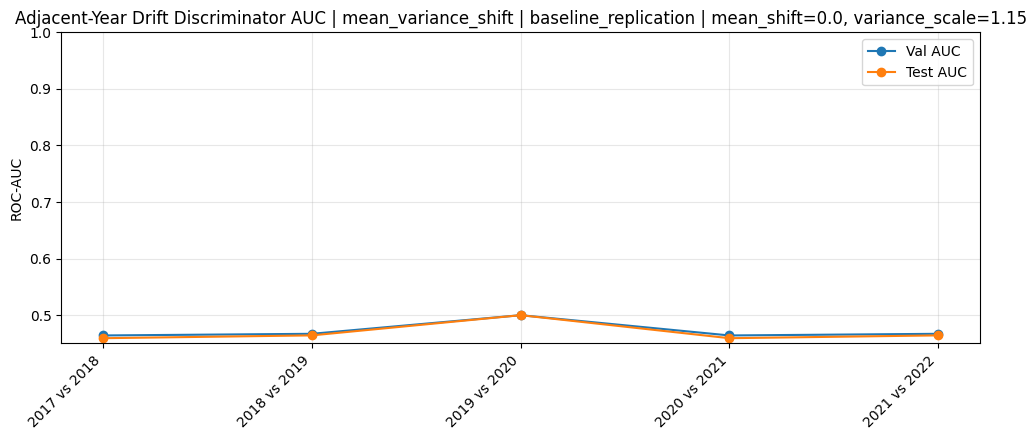


### Running artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.0
Artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.0
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.0_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9507 | Test AUC = 0.9556 | Val F1 = 0.8996 | Test F1 = 0.9023

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9506 | Test AUC = 0.9555 | Val F1 = 0.8996 | Test F1 = 0.9016

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6223 | Test F1 = 0.6186

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9507 | Test AUC = 0.9556 | Val F1 = 0.8996 | Test F1 = 0.9023

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9506 | Test AUC = 0.9555 | Val F1 = 0.8996 | Test F1 = 0.9016

COMPLETE: mean_variance_shift | baseline_replication | m

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.955568
1,2018 vs 2019,2018,2019,0.955541
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.955568
4,2021 vs 2022,2021,2022,0.955541


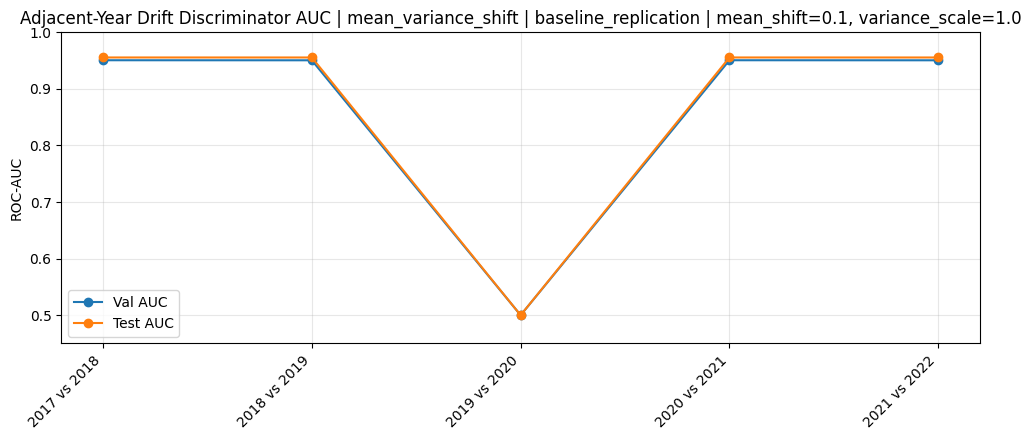


### Running artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.15
Artifact: mean_variance_shift | baseline_replication | mean_shift=0.1, variance_scale=1.15
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.15_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9373 | Test AUC = 0.9386 | Val F1 = 0.8657 | Test F1 = 0.8665

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9372 | Test AUC = 0.9386 | Val F1 = 0.8704 | Test F1 = 0.8695

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6223 | Test F1 = 0.6186

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9373 | Test AUC = 0.9386 | Val F1 = 0.8657 | Test F1 = 0.8665

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9372 | Test AUC = 0.9386 | Val F1 = 0.8704 | Test F1 = 0.8695

COMPLETE: mean_variance_shift | baseline_replication 

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.938624
1,2018 vs 2019,2018,2019,0.938593
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.938624
4,2021 vs 2022,2021,2022,0.938593


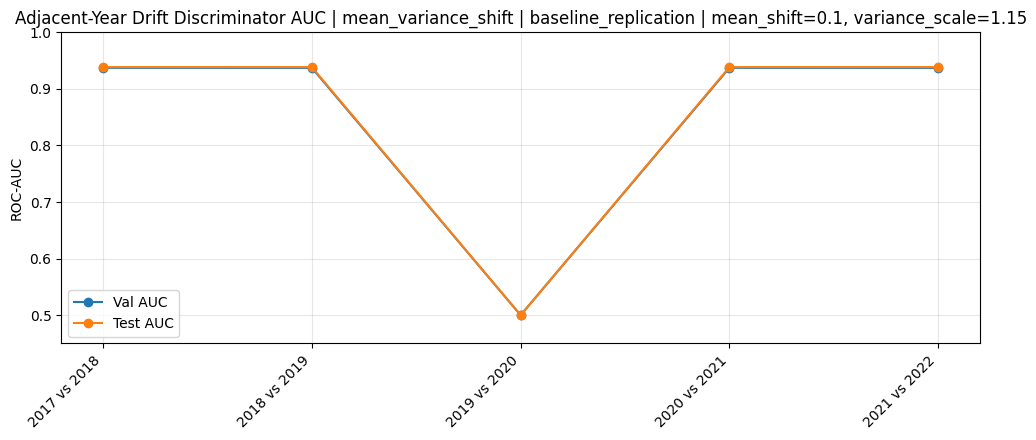


### Running artifact: mean_variance_shift | per_year_original | mean_shift=0.0, variance_scale=1.15
Artifact: mean_variance_shift | per_year_original | mean_shift=0.0, variance_scale=1.15
Dataset: synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-mean_variance_shift_severity-mean_shift0.0-variance_scale1.15_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.6846 | Test AUC = 0.6829 | Val F1 = 0.6519 | Test F1 = 0.6606

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.7337 | Test AUC = 0.7224 | Val F1 = 0.6707 | Test F1 = 0.6657

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5620 | Test AUC = 0.5404 | Val F1 = 0.5596 | Test F1 = 0.5372

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.5837 | Test AUC = 0.5744 | Val F1 = 0.5484 | Test F1 = 0.5491

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.6715 | Test AUC = 0.6812 | Val F1 = 0.6393 | Test F1 = 0.6478

COMPLETE: mean_variance_shift | per_year_original | mean_shift=0.0, variance_sc

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.682923,0.678537
1,2018 vs 2019,2018,2019,0.722384,0.722240
2,2019 vs 2020,2019,2020,0.540419,0.540399
3,2020 vs 2021,2020,2021,0.574421,0.571939
4,2021 vs 2022,2021,2022,0.681155,0.675960


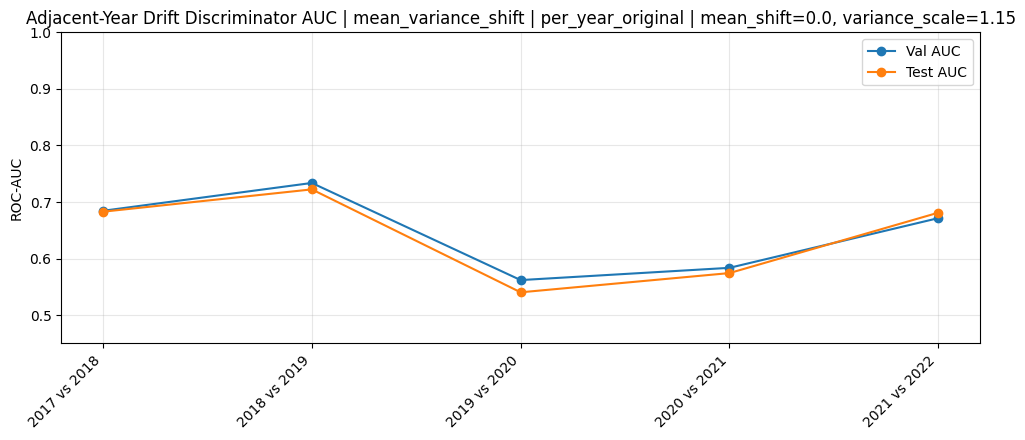


### Running artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.0
Artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.0
Dataset: synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.0_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9192 | Test AUC = 0.9202 | Val F1 = 0.8540 | Test F1 = 0.8576

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9320 | Test AUC = 0.9401 | Val F1 = 0.8741 | Test F1 = 0.8818

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5621 | Test AUC = 0.5404 | Val F1 = 0.5597 | Test F1 = 0.5372

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9479 | Test AUC = 0.9557 | Val F1 = 0.8943 | Test F1 = 0.9051

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9387 | Test AUC = 0.9497 | Val F1 = 0.8811 | Test F1 = 0.8926

COMPLETE: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.920160,0.678537
1,2018 vs 2019,2018,2019,0.940136,0.722240
2,2019 vs 2020,2019,2020,0.540417,0.540399
3,2020 vs 2021,2020,2021,0.955683,0.571939
4,2021 vs 2022,2021,2022,0.949674,0.675960


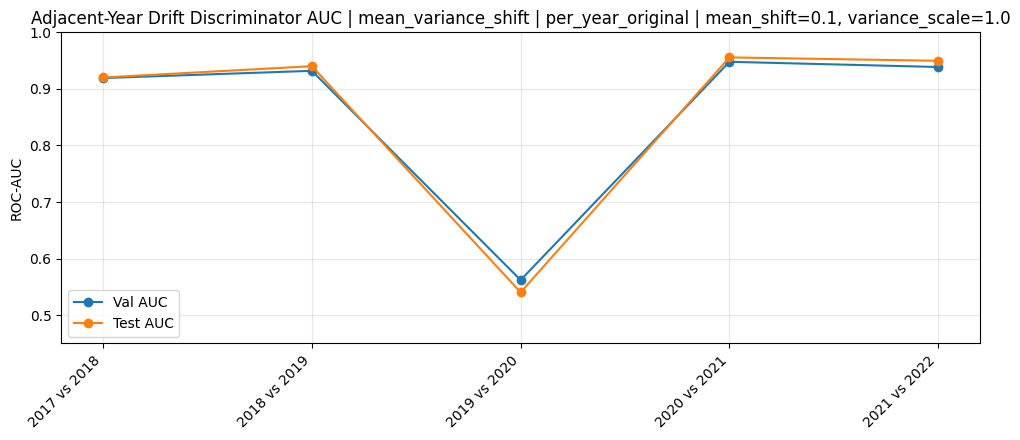


### Running artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.15
Artifact: mean_variance_shift | per_year_original | mean_shift=0.1, variance_scale=1.15
Dataset: synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-mean_variance_shift_severity-mean_shift0.1-variance_scale1.15_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.8934 | Test AUC = 0.8922 | Val F1 = 0.8091 | Test F1 = 0.8132

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9168 | Test AUC = 0.9221 | Val F1 = 0.8465 | Test F1 = 0.8494

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5620 | Test AUC = 0.5404 | Val F1 = 0.5596 | Test F1 = 0.5372

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9303 | Test AUC = 0.9360 | Val F1 = 0.8543 | Test F1 = 0.8635

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9209 | Test AUC = 0.9315 | Val F1 = 0.8514 | Test F1 = 0.8607

COMPLETE: mean_variance_shift | per_year_original | mean_shift=0.1, variance_sc

,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.892166,0.678537
1,2018 vs 2019,2018,2019,0.922061,0.722240
2,2019 vs 2020,2019,2020,0.540442,0.540399
3,2020 vs 2021,2020,2021,0.936048,0.571939
4,2021 vs 2022,2021,2022,0.931505,0.675960


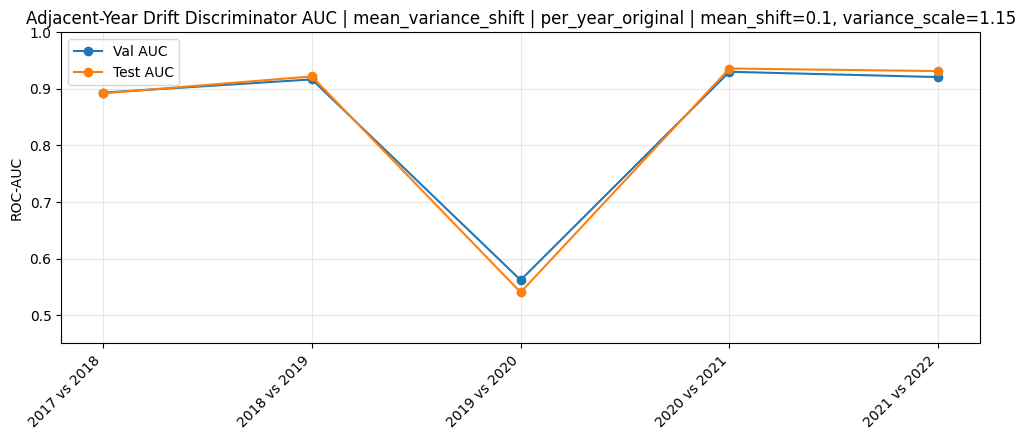

mean_variance_shift combined view:


,mode,severity_display,AUC,n_pairs,"AUC (original, unmodified)"
0,baseline_replication,"mean_shift=0.0, variance_scale=1.15",0.469438,5,NaN
1,baseline_replication,"mean_shift=0.1, variance_scale=1.0",0.864444,5,NaN
2,baseline_replication,"mean_shift=0.1, variance_scale=1.15",0.850887,5,NaN
3,per_year_original,"mean_shift=0.0, variance_scale=1.15",0.640260,5,0.637815
4,per_year_original,"mean_shift=0.1, variance_scale=1.0",0.861214,5,0.637815
5,per_year_original,"mean_shift=0.1, variance_scale=1.15",0.844444,5,0.637815


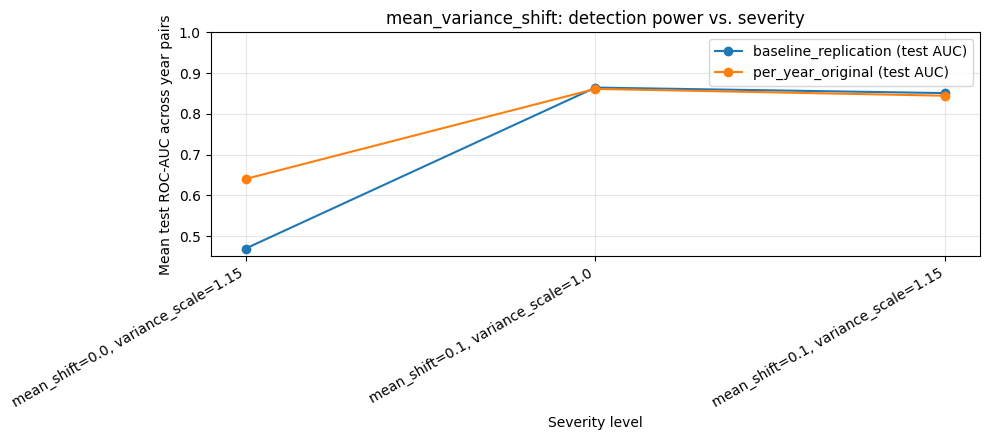

In [ ]:
section_results["mean_variance_shift"] = run_method_section(
    method_name="mean_variance_shift",
    sample_fraction=SAMPLE_FRACTION,
 )

mean_combined = section_results["mean_variance_shift"]["combined"]
mean_summary = summarize_and_plot_section(mean_combined, "mean_variance_shift")

## Covariance Shift

Run discriminator on synthetic artifacts generated with `covariance_shift` for both modes.


### Running artifact: covariance_shift | baseline_replication | 0.05
Artifact: covariance_shift | baseline_replication | 0.05
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-covariance_shift_severity-0.05_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9481 | Test AUC = 0.9463 | Val F1 = 0.8905 | Test F1 = 0.8870

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9481 | Test AUC = 0.9464 | Val F1 = 0.8878 | Test F1 = 0.8831

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6223 | Test F1 = 0.6186

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9481 | Test AUC = 0.9463 | Val F1 = 0.8905 | Test F1 = 0.8870

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9481 | Test AUC = 0.9464 | Val F1 = 0.8878 | Test F1 = 0.8831

COMPLETE: covariance_shift | baseline_replication | 0.05
Elapsed: 267.3s (4.5m)
Pairs trained: 5
Average time per pair: 53.4s
Min/Max AUC (test): 0.500 

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.946348
1,2018 vs 2019,2018,2019,0.946367
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.946348
4,2021 vs 2022,2021,2022,0.946367


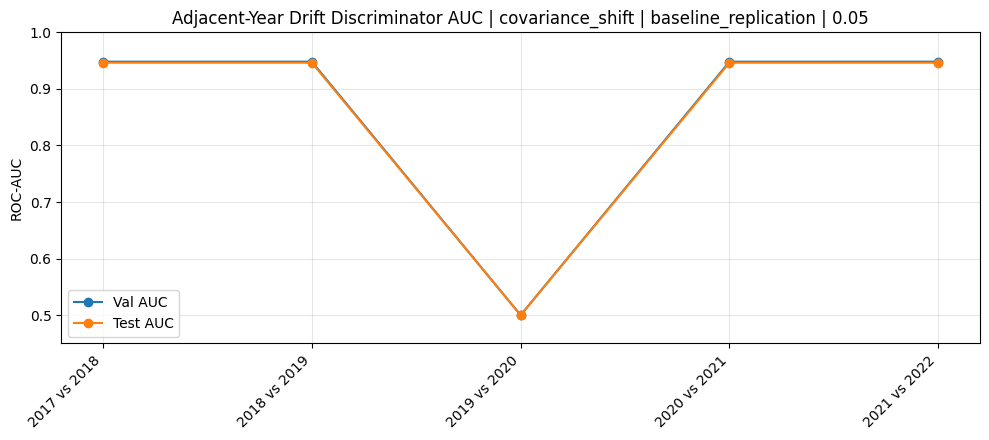


### Running artifact: covariance_shift | baseline_replication | 0.15
Artifact: covariance_shift | baseline_replication | 0.15
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-covariance_shift_severity-0.15_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9995 | Test AUC = 0.9994 | Val F1 = 0.9967 | Test F1 = 0.9962

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9995 | Test AUC = 0.9994 | Val F1 = 0.9967 | Test F1 = 0.9961

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6223 | Test F1 = 0.6186

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9995 | Test AUC = 0.9994 | Val F1 = 0.9967 | Test F1 = 0.9962

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9995 | Test AUC = 0.9994 | Val F1 = 0.9967 | Test F1 = 0.9961

COMPLETE: covariance_shift | baseline_replication | 0.15
Elapsed: 243.6s (4.1m)
Pairs trained: 5
Average time per pair: 48.7s
Min/Max AUC (test): 0.500 

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.999362
1,2018 vs 2019,2018,2019,0.999364
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.999362
4,2021 vs 2022,2021,2022,0.999364


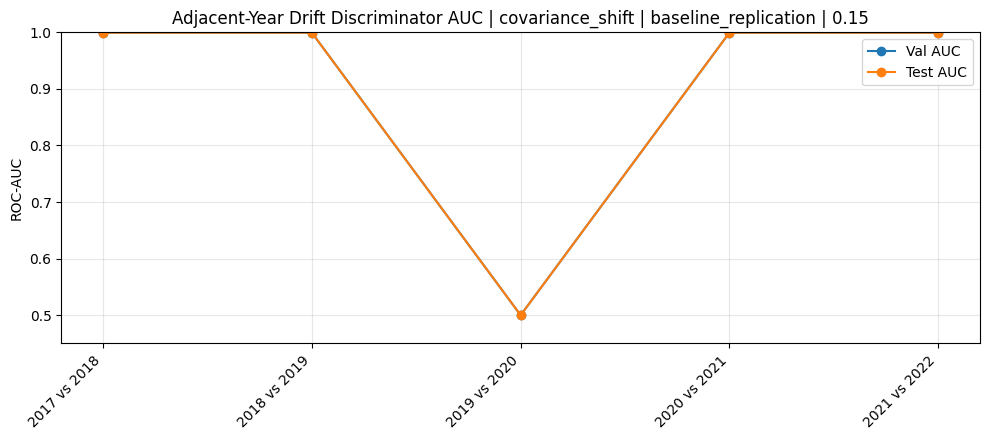


### Running artifact: covariance_shift | baseline_replication | 0.3
Artifact: covariance_shift | baseline_replication | 0.3
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-covariance_shift_severity-0.3_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 1.0000 | Test AUC = 0.9999 | Val F1 = 0.9997 | Test F1 = 0.9996

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 1.0000 | Test AUC = 0.9999 | Val F1 = 0.9997 | Test F1 = 0.9996

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6223 | Test F1 = 0.6186

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 1.0000 | Test AUC = 0.9999 | Val F1 = 0.9997 | Test F1 = 0.9996

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 1.0000 | Test AUC = 0.9999 | Val F1 = 0.9997 | Test F1 = 0.9996

COMPLETE: covariance_shift | baseline_replication | 0.3
Elapsed: 241.5s (4.0m)
Pairs trained: 5
Average time per pair: 48.3s
Min/Max AUC (test): 0.500 / 1.

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.999939
1,2018 vs 2019,2018,2019,0.999938
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.999939
4,2021 vs 2022,2021,2022,0.999938


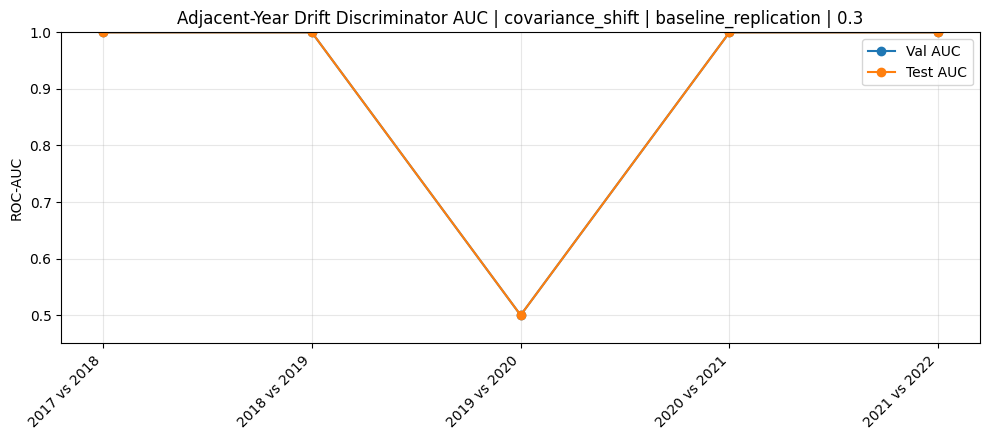


### Running artifact: covariance_shift | per_year_original | 0.05
Artifact: covariance_shift | per_year_original | 0.05
Dataset: synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-covariance_shift_severity-0.05_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9661 | Test AUC = 0.9665 | Val F1 = 0.9214 | Test F1 = 0.9220

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9781 | Test AUC = 0.9730 | Val F1 = 0.9390 | Test F1 = 0.9314

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5621 | Test AUC = 0.5404 | Val F1 = 0.5596 | Test F1 = 0.5372

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9405 | Test AUC = 0.9431 | Val F1 = 0.8873 | Test F1 = 0.8911

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9478 | Test AUC = 0.9495 | Val F1 = 0.8955 | Test F1 = 0.8961

COMPLETE: covariance_shift | per_year_original | 0.05
Elapsed: 310.5s (5.2m)
Pairs trained: 5
Average time per pair: 62.0s
Min/Max AUC (test): 0.540 / 0.973



,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.966521,0.678537
1,2018 vs 2019,2018,2019,0.973006,0.722240
2,2019 vs 2020,2019,2020,0.540393,0.540399
3,2020 vs 2021,2020,2021,0.943102,0.571939
4,2021 vs 2022,2021,2022,0.949513,0.675960


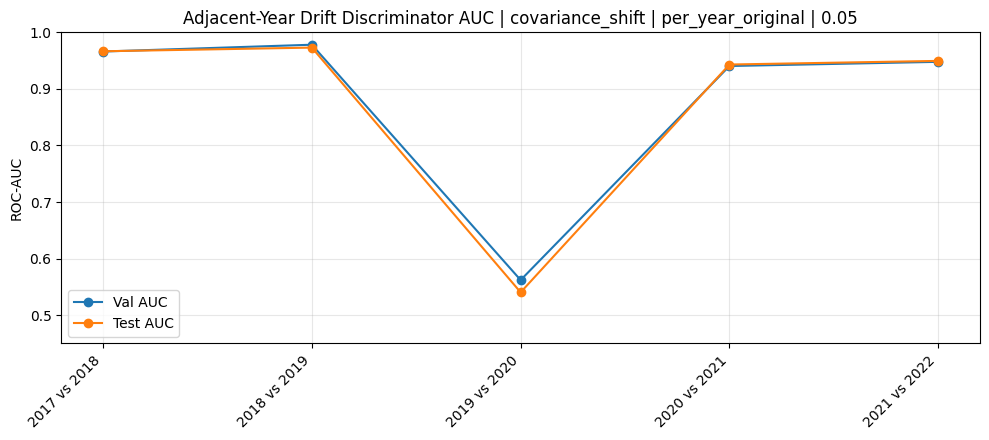


### Running artifact: covariance_shift | per_year_original | 0.15
Artifact: covariance_shift | per_year_original | 0.15
Dataset: synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-covariance_shift_severity-0.15_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9990 | Test AUC = 0.9988 | Val F1 = 0.9963 | Test F1 = 0.9962

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9993 | Test AUC = 0.9991 | Val F1 = 0.9974 | Test F1 = 0.9963

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5621 | Test AUC = 0.5404 | Val F1 = 0.5596 | Test F1 = 0.5371

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9987 | Test AUC = 0.9987 | Val F1 = 0.9944 | Test F1 = 0.9945

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9986 | Test AUC = 0.9988 | Val F1 = 0.9947 | Test F1 = 0.9947

COMPLETE: covariance_shift | per_year_original | 0.15
Elapsed: 348.8s (5.8m)
Pairs trained: 5
Average time per pair: 69.7s
Min/Max AUC (test): 0.540 / 0.999



,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.998849,0.678537
1,2018 vs 2019,2018,2019,0.999073,0.722240
2,2019 vs 2020,2019,2020,0.540384,0.540399
3,2020 vs 2021,2020,2021,0.998712,0.571939
4,2021 vs 2022,2021,2022,0.998789,0.675960


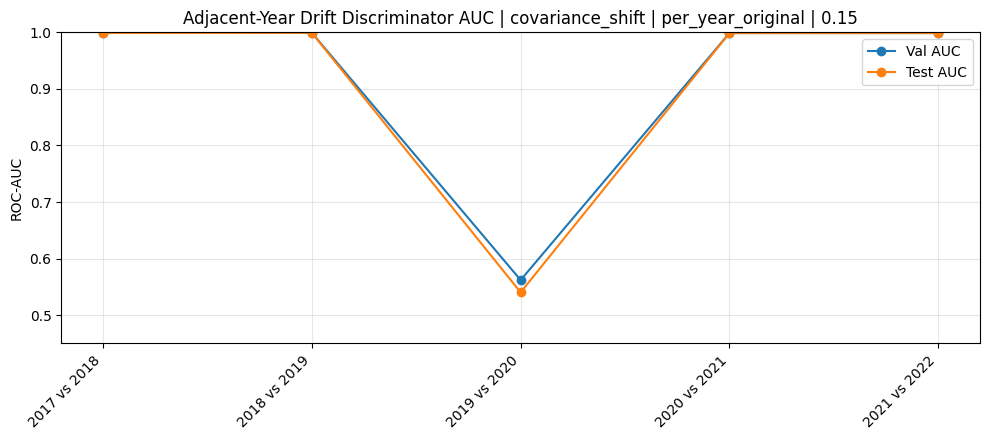


### Running artifact: covariance_shift | per_year_original | 0.3
Artifact: covariance_shift | per_year_original | 0.3
Dataset: synthetic_drift_data\section_b_per_year_original\synthetic_mode-per_year_original_method-covariance_shift_severity-0.3_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.9997 | Test AUC = 0.9996 | Val F1 = 0.9991 | Test F1 = 0.9990

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.9997 | Test AUC = 0.9996 | Val F1 = 0.9992 | Test F1 = 0.9990

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5621 | Test AUC = 0.5404 | Val F1 = 0.5596 | Test F1 = 0.5371

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.9996 | Test AUC = 0.9996 | Val F1 = 0.9990 | Test F1 = 0.9989

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.9997 | Test AUC = 0.9997 | Val F1 = 0.9990 | Test F1 = 0.9989

COMPLETE: covariance_shift | per_year_original | 0.3
Elapsed: 378.5s (6.3m)
Pairs trained: 5
Average time per pair: 75.6s
Min/Max AUC (test): 0.540 / 1.000



,pair,year_t_minus_1,year_t,AUC,"AUC (original, unmodified)"
0,2017 vs 2018,2017,2018,0.999590,0.678537
1,2018 vs 2019,2018,2019,0.999603,0.722240
2,2019 vs 2020,2019,2020,0.540375,0.540399
3,2020 vs 2021,2020,2021,0.999624,0.571939
4,2021 vs 2022,2021,2022,0.999674,0.675960


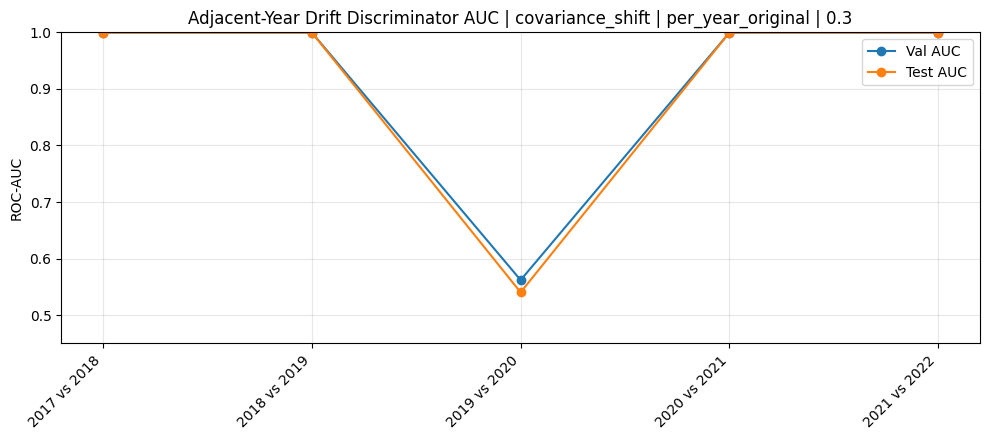

covariance_shift combined view:


,mode,severity_display,AUC,n_pairs,"AUC (original, unmodified)"
0,baseline_replication,0.05,0.857086,5,NaN
1,baseline_replication,0.15,0.899491,5,NaN
2,baseline_replication,0.3,0.899951,5,NaN
3,per_year_original,0.05,0.874507,5,0.637815
4,per_year_original,0.15,0.907161,5,0.637815
5,per_year_original,0.3,0.907773,5,0.637815


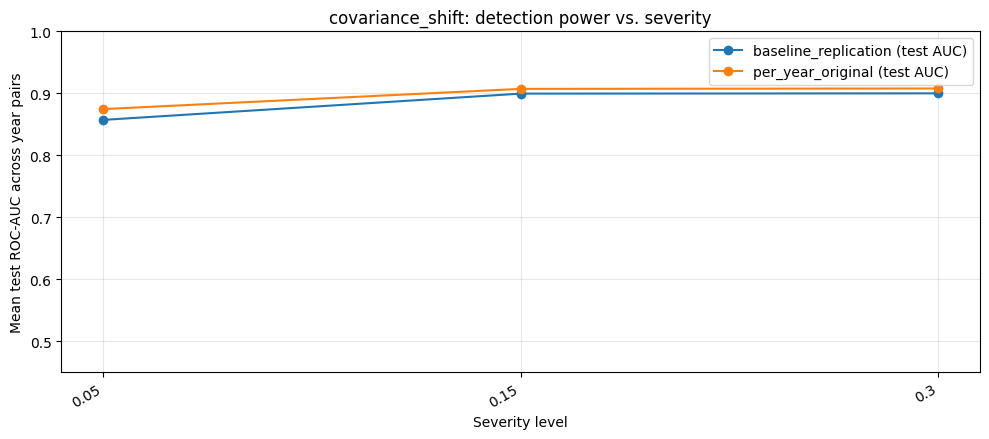

In [ ]:
section_results["covariance_shift"] = run_method_section(
    method_name="covariance_shift",
    sample_fraction=SAMPLE_FRACTION,
 )

cov_combined = section_results["covariance_shift"]["combined"]
cov_summary = summarize_and_plot_section(cov_combined, "covariance_shift")

## Noise Injection

Run discriminator on synthetic artifacts generated with `noise_injection` for both modes.


### Running artifact: noise_injection | baseline_replication | 0.04
Artifact: noise_injection | baseline_replication | 0.04
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-noise_injection_severity-0.04_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6234 | Test F1 = 0.6197

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6213 | Test F1 = 0.6176

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6223 | Test F1 = 0.6186

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6179 | Test F1 = 0.6136

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6251 | Test F1 = 0.6218

COMPLETE: noise_injection | baseline_replication | 0.04
Elapsed: 336.8s (5.6m)
Pairs trained: 5
Average time per pair: 67.3s
Min/Max AUC (test): 0.500 / 0.

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.500003
1,2018 vs 2019,2018,2019,0.500000
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.499984
4,2021 vs 2022,2021,2022,0.500025


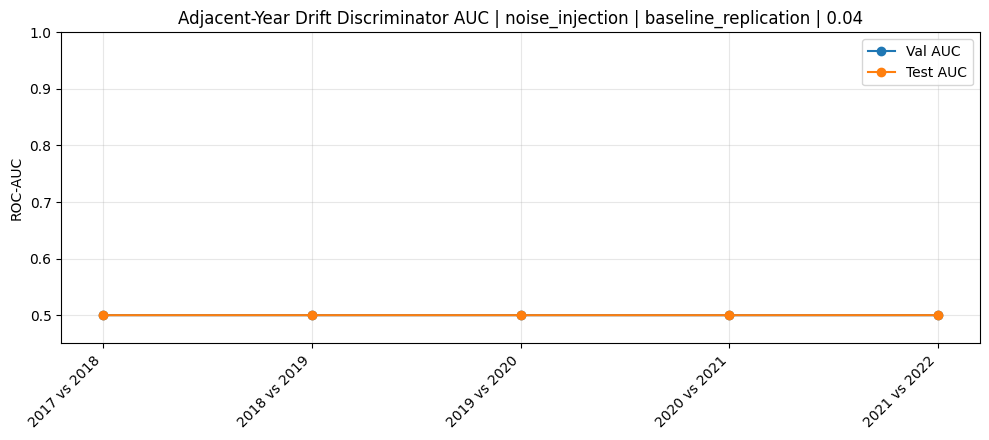


### Running artifact: noise_injection | baseline_replication | 0.08
Artifact: noise_injection | baseline_replication | 0.08
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-noise_injection_severity-0.08_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6238 | Test F1 = 0.6203

[2/5] 2018 vs 2019
  RESULTS: Val AUC = 0.4999 | Test AUC = 0.5000 | Val F1 = 0.6210 | Test F1 = 0.6170

[3/5] 2019 vs 2020
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6223 | Test F1 = 0.6186

[4/5] 2020 vs 2021
  RESULTS: Val AUC = 0.4999 | Test AUC = 0.5000 | Val F1 = 0.6093 | Test F1 = 0.6058

[5/5] 2021 vs 2022
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5000 | Val F1 = 0.6286 | Test F1 = 0.6252

COMPLETE: noise_injection | baseline_replication | 0.08
Elapsed: 300.8s (5.0m)
Pairs trained: 5
Average time per pair: 60.1s
Min/Max AUC (test): 0.500 / 0.

,pair,year_t_minus_1,year_t,AUC
0,2017 vs 2018,2017,2018,0.500006
1,2018 vs 2019,2018,2019,0.500006
2,2019 vs 2020,2019,2020,0.500000
3,2020 vs 2021,2020,2021,0.499962
4,2021 vs 2022,2021,2022,0.500048


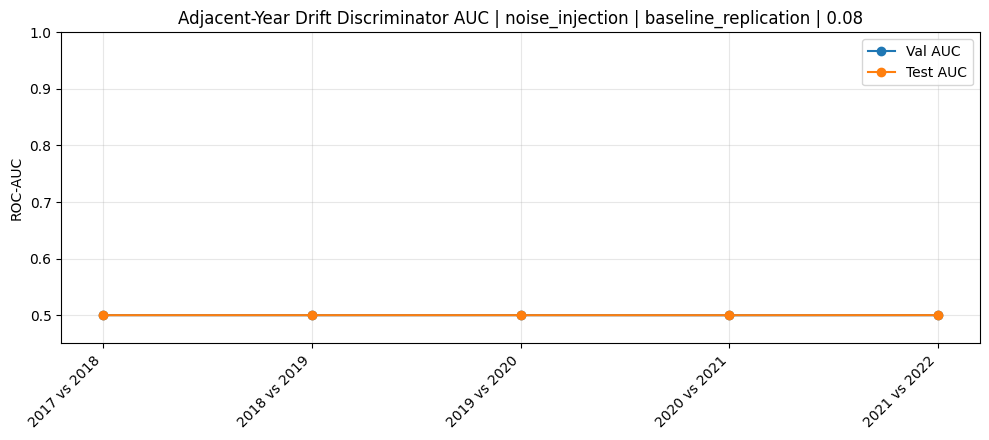


### Running artifact: noise_injection | baseline_replication | 0.16
Artifact: noise_injection | baseline_replication | 0.16
Dataset: synthetic_drift_data\section_a_baseline_replication\synthetic_mode-baseline_replication_method-noise_injection_severity-0.16_baseline-2018_perturbed-2018-2021.zarr
Pairs to evaluate: 5

[1/5] 2017 vs 2018
  RESULTS: Val AUC = 0.5000 | Test AUC = 0.5001 | Val F1 = 0.6209 | Test F1 = 0.6181

[2/5] 2018 vs 2019


In [ ]:
section_results["noise_injection"] = run_method_section(
    method_name="noise_injection",
    sample_fraction=SAMPLE_FRACTION,
 )

noise_combined = section_results["noise_injection"]["combined"]
noise_summary = summarize_and_plot_section(noise_combined, "noise_injection")

## Cross-Method Summary

Consolidate all method runs into one comparison table and aggregate chart.

In [ ]:
available = {
    k: v for k, v in section_results.items()
    if isinstance(v, dict) and not v.get("combined", pd.DataFrame()).empty
}

if not available:
    print("No method results available yet. Run the method section cells first.")
else:
    all_results = pd.concat([v["combined"] for v in available.values()], ignore_index=True)
    print(f"Collected rows: {len(all_results)}")
    display(
        to_auc_display(
            all_results, ["method", "mode", "severity_display", "pair", "year_t_minus_1", "year_t"]
        ).head()
    )

    summary = (
        all_results.groupby(["method", "mode", "severity_display"], as_index=False, sort=False)
        .agg(
            mean_test_auc=("test_auc", "mean"),
            n_pairs=("pair", "count"),
        )
        .sort_values(["method", "mode"], kind="stable")
        .reset_index(drop=True)
    )

    print("Method/mode/severity summary:")
    plot_df = summary.rename(columns={"mean_test_auc": "AUC"})
    is_pyo = plot_df["mode"] == "per_year_original"
    if original_reference_mean_auc is not None and is_pyo.any():
        plot_df.loc[is_pyo, "AUC (original, unmodified)"] = original_reference_mean_auc
    display(plot_df)

    # x-axis is one bar per (method, mode, severity) artifact - averaging away severity here
    # (as the original method-only chart did) would hide the whole point of the sweep.
    plot_df["artifact_label"] = (
        plot_df["method"] + " | " + plot_df["mode"] + " | " + plot_df["severity_display"]
    )
    bar_cols = [c for c in ["AUC", "AUC (original, unmodified)"] if c in plot_df.columns]
    ax = plot_df.plot(
        x="artifact_label",
        y=bar_cols,
        kind="bar",
        figsize=(14, 5),
        rot=75,
        title="Average AUC by Synthetic Artifact (method | mode | severity)",
    )
    ax.set_xlabel("")
    ax.set_ylabel("ROC-AUC")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()